# Data-Driven Optimization with Machine Learning Applications
## Assignment II 


**Student Name:** ***Joachim SINYABE DANBE***

*AIMS RWANDA*

In [2]:
from gekko import GEKKO

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset


# Question 1

Unconstrained Optimization Problem

min $f(x) = x_1²·e^(1-x_1²) - 20.25(x_1 - x_2)²$


### 1a

```bash
pip install gekko
```

### 1b)

In [3]:
model  = GEKKO(remote=False)

x1 = model.Var() 
x2 = model.Var()

model.Obj(x1**2 * model.exp(1 - x1**2) - 20.25*(x1 - x2)**2)

model.options.SOLVER = 3
model.solve(disp = False)

print(f"Optimal x1 = {x1.value[0]:.3f}")
print(f"Optimal x2 = {x2.value[0]:.3f}")
print(f"Optimal objective value = {model.options.OBJFCNVAL:.3f}")


Optimal x1 = 0.000
Optimal x2 = 0.000
Optimal objective value = 0.000


The solver found a local minimum for the defined function, At the point \((0,0)\), the function value is 0.0

# Question 2

### 2a: Data Points

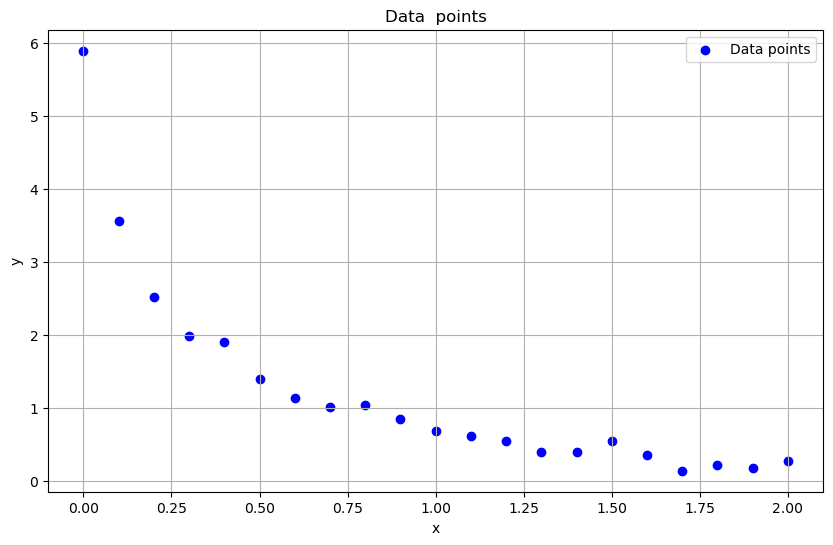

In [4]:
x_value = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 
                   1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

y_value = np.array([5.8955, 3.5639, 2.5173, 1.9790, 1.8990, 1.3938, 1.1359, 
                   1.0096, 1.0343, 0.8435, 0.6856, 0.6100, 0.5392, 0.3946, 
                   0.3903, 0.5474, 0.3459, 0.1370, 0.2211, 0.1704, 0.2636])


plt.figure(figsize = (10,6))
plt.scatter(x_value,y_value, color = 'blue', label = 'Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data  points')
plt.grid(True)
plt.legend()

### 2b:  Parameters $w_1, w_2, w_3, w_4$

We need to fit the model:
$$F(x, w) = w_1 e^{-w_3 x} + w_2 e^{-w_4 x}$$

This is done by minimizing the sum of squared residuals:
$$\min_{w_1, w_2, w_3, w_4} \sum_{j=1}^{n} \left(F(x^{(j)}, w) - y^{(j)}\right)^2$$

In [5]:
model = GEKKO()

w1 = model.FV(value=1, lb=0); w1.STATUS = 1
w2 = model.FV(value=1, lb=0); w2.STATUS = 1
w3 = model.FV(value=1, lb=0); w3.STATUS = 1
w4 = model.FV(value=1, lb=0); w4.STATUS = 1

yhat = [model.Var() for _ in range(len(x_value))]

# Modèle
for i in range(len(x_value)):
    model.Equation(
        yhat[i] == w1*model.exp(-w3*x_value[i]) + w2*model.exp(-w4*x_value[i])
    )
    model.Minimize((yhat[i] - y_value[i])**2)

model.solve(disp=False)
    
print(f"Optimal w1: {w1.value[0]:.4f}")
print(f"Optimal w2: {w2.value[0]:.4f}")
print(f"Optimal w3: {w3.value[0]:.4f}")
print(f"Optimal w4: {w4.value[0]:.4f}")


Optimal w1: 2.8890
Optimal w2: 3.0069
Optimal w3: 1.4003
Optimal w4: 10.5864


These are the specific parameter values that minimize the difference between the model's prediction and the actual data points.

### 2c: Data Points and Fitting Curve

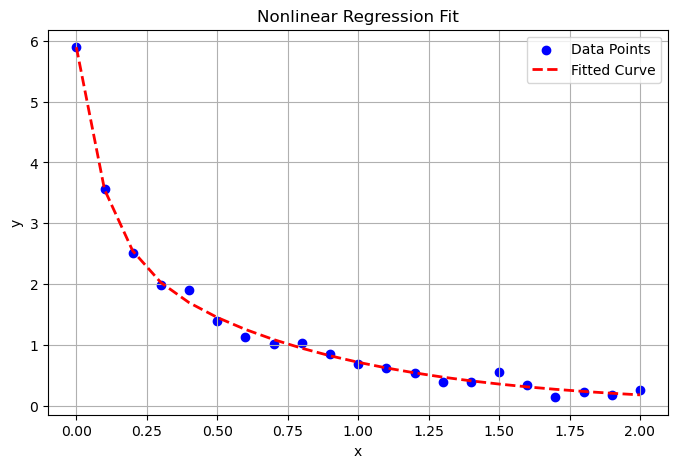

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(x_value, y_value, color='blue', label='Data Points')
plt.plot(x_value, yhat, color='red', linestyle='--', linewidth=2, label='Fitted Curve')
plt.title('Nonlinear Regression Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


The optimization process successfully estimated the weights for the two exponential decay terms. The resulting fitted curve plot shows that the model curve (red dashed line) passes to the actual data points (blue dots), indicating a fit to the observed data trend. 

Original data points alongside the curve generated by the fitted parameters

# Question 3

### 3a: Preprocess Data

In [34]:
data = pd.read_csv('SAHeart.csv')

print(data.head())

   row.names  sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  \
0          1  160    12.00  5.73      23.11  Present     49    25.30    97.20   
1          2  144     0.01  4.41      28.61   Absent     55    28.87     2.06   
2          3  118     0.08  3.48      32.28  Present     52    29.14     3.81   
3          4  170     7.50  6.41      38.03  Present     51    31.99    24.26   
4          5  134    13.60  3.50      27.78  Present     60    25.99    57.34   

   age  chd  
0   52    1  
1   63    1  
2   46    0  
3   58    1  
4   49    1  


In [35]:
data['famhist'] = data['famhist'].map({'Present': 1, 'Absent': 0})
print(data.head())

   row.names  sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  \
0          1  160    12.00  5.73      23.11        1     49    25.30    97.20   
1          2  144     0.01  4.41      28.61        0     55    28.87     2.06   
2          3  118     0.08  3.48      32.28        1     52    29.14     3.81   
3          4  170     7.50  6.41      38.03        1     51    31.99    24.26   
4          5  134    13.60  3.50      27.78        1     60    25.99    57.34   

   age  chd  
0   52    1  
1   63    1  
2   46    0  
3   58    1  
4   49    1  


### 3b: Logistic Regression Model

We used pipeline to first scale the data (StandardScaler) and then apply logistic regression (LogisticRegression). The model's accuracy is evaluated using the test set and a confusion matrix is visualized.

In [36]:
X = data[['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist',
          'typea', 'obesity', 'alcohol', 'age']]
y = data['chd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=500, solver='lbfgs'))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7500


The model correctly classified the test patients (as having CHD or not) approximately $75\%$ of the time. This is a promising result, suggesting the model is useful for prediction.

Text(0.5, 23.52222222222222, 'Predicted')

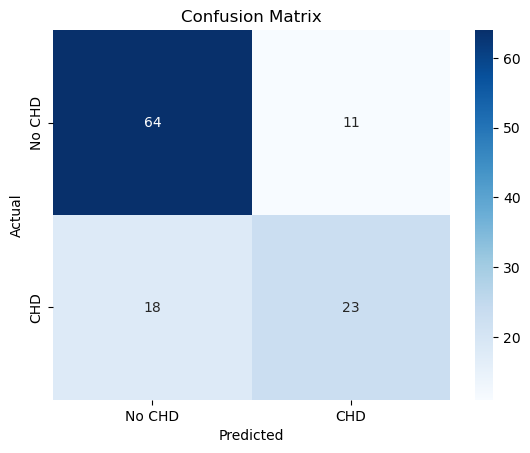

In [37]:
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No CHD', 'CHD'], 
            yticklabels=['No CHD', 'CHD'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

The matrix visualizes where the model succeeded or failed.

    64 patients without CHD were correctly predicted as "No CHD".
    23 patients with CHD were correctly predicted as "CHD".
    18 patients with CHD were incorrectly predicted as "No CHD" (false negatives).
    11 patients without CHD were incorrectly predicted as "CHD" (false positives).

### 3c: Risk for New Patient

In [38]:
patient = np.array([[133, 3.3, 4.6, 34.5, 1, 30, 32, 20, 44]])

risk_prediction = pipeline.predict(patient)
risk_proba = pipeline.predict_proba(patient)

print(f"High risk of CHD: {risk_prediction[0]}")
print(f"Probability of CHD: {risk_proba[0][1]:.2f}")

High risk of CHD: 0
Probability of CHD: 0.19


/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


This patient is at ***LOW RISK*** of coronary heart disease with probability of 19% of CHD

### 3d: Most Determinant Factors

In [39]:
coefficients = pipeline.named_steps['logreg'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})
imp = feature_importance.sort_values(by='Coefficient', ascending=False)
print(imp)


     Feature  Coefficient
8        age     0.642099
4    famhist     0.385765
2        ldl     0.353841
5      typea     0.340346
1    tobacco     0.259679
0        sbp     0.245249
3  adiposity     0.192220
7    alcohol     0.067418
6    obesity    -0.310832


In [40]:
print("\nTop 3 Most Determinant Factors:")
print(imp[:3])


Top 3 Most Determinant Factors:
   Feature  Coefficient
8      age     0.642099
4  famhist     0.385765
2      ldl     0.353841


The analysis identified age, famhist (family history) and low densiity lipoprotein cholesterol level as the top three most influential factors, sorted by their positive coefficients

### 3e: Effect of Family History on CHD Risk

In [41]:
family_history_effect = feature_importance.loc[
    feature_importance['Feature'] == 'famhist'
]

print("Impact of family history on CHD risk:")
print(family_history_effect)

Impact of family history on CHD risk:
   Feature  Coefficient
4  famhist     0.385765


The coefficient is positive.

Having a family history (famhist = 1) increases the risk of CHD.


# Question 4

In [42]:
np.random.seed(42)
torch.manual_seed(42)

In [43]:
data = pd.read_csv('SolarPrediction.csv')

data.head(10)
print("Dataset Shape:", data.shape)

Dataset Shape: (32686, 11)


In [44]:
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB
None


**4a) Data Exploration**

In [45]:
print("Missing Values Count:")
missing_values = data.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values Count:
UNIXTime                  0
Data                      0
Time                      0
Radiation                 0
Temperature               0
Pressure                  0
Humidity                  0
WindDirection(Degrees)    0
Speed                     0
TimeSunRise               0
TimeSunSet                0
dtype: int64

Total missing values: 0


There is no missing values in the data set

In [46]:
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


No dupliate rows

 Features: pressure, wind direction, wind speed, humidity, temperature
 
 Target: Radiation (solar_radiation)

In [47]:
features = ['Pressure', 'Temperature', 'Humidity', 'WindDirection(Degrees)', 'Speed',
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
target = 'Radiation'

data['DateTime'] = pd.to_datetime(data['Data'] + ' ' + data['Time'])

data['hour'] = data['DateTime'].dt.hour
data['month'] = data['DateTime'].dt.month
data['day_of_year'] = data['DateTime'].dt.dayofyear

#  hour (0-23)
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)

# year (1-365)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_year'] / 365)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_year'] / 365)


/tmp/ipykernel_664784/815093439.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DateTime'] = pd.to_datetime(data['Data'] + ' ' + data['Time'])


In [48]:
data_clean = data[features+[target]].copy()

print("Selected features and target:")
print(data_clean.head())
print(f"\nClean dataset shape: {data_clean.shape}")

Selected features and target:
   Pressure  Temperature  Humidity  WindDirection(Degrees)  Speed  hour_sin  \
0     30.46           48        59                  177.39   5.62 -0.258819   
1     30.46           48        58                  176.78   3.37 -0.258819   
2     30.46           48        57                  158.75   3.37 -0.258819   
3     30.46           48        60                  137.71   3.37 -0.258819   
4     30.46           48        62                  104.95   5.62 -0.258819   

   hour_cos   day_sin  day_cos  Radiation  
0  0.965926 -0.999917 -0.01291       1.21  
1  0.965926 -0.999917 -0.01291       1.21  
2  0.965926 -0.999917 -0.01291       1.23  
3  0.965926 -0.999917 -0.01291       1.21  
4  0.965926 -0.999917 -0.01291       1.17  

Clean dataset shape: (32686, 10)


***4b )Neural Network Design***

In [49]:
X = data_clean[features].values
y = data_clean[target].values.reshape(-1, 1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (32686, 9)
Target shape: (32686, 1)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 24514 samples
Test set: 8172 samples


In [51]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

PyTorch tensors Convertion

In [52]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

We work with four layer, the first is the input layer which represnet the feature, two hidden (the fisrt with 64 units, and the second one woth 32 units) and the output layer with one unit.


The activation function used is ReLu

In [53]:
class SolarNet(nn.Module):
    def __init__(self,input_size):
        super(SolarNet, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x


model = SolarNet(len(features))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  

***4c) Training and Validation***

Epoch [10/100], Loss: 0.8510
Epoch [20/100], Loss: 0.6511
Epoch [30/100], Loss: 0.4341
Epoch [40/100], Loss: 0.2678
Epoch [50/100], Loss: 0.2198
Epoch [60/100], Loss: 0.2016
Epoch [70/100], Loss: 0.1824
Epoch [80/100], Loss: 0.1719
Epoch [90/100], Loss: 0.1636
Epoch [100/100], Loss: 0.1572


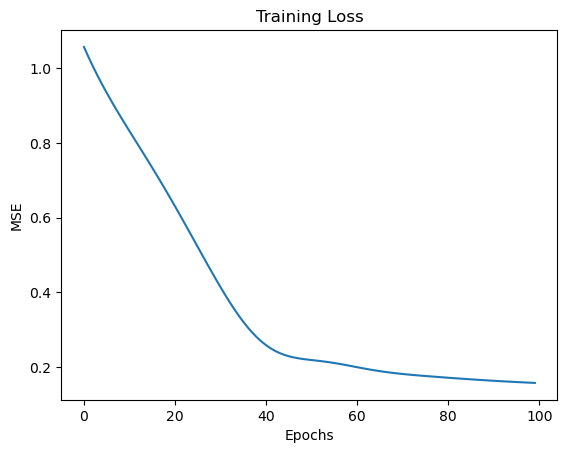

In [54]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

The model is **converging**. This is a fancy way of saying the model is getting better and better at its job. Since the curve is very flat by epoch $100$, it suggests that training for much longer might not make the model much better; it has likely learned most of what it can from this data.

***4c) Evaluation***

In [55]:
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_tensor).numpy()


y_pred_final = scaler_y.inverse_transform(predictions_scaled)
y_true_final = scaler_y.inverse_transform(y_test_tensor.numpy())


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_true_final, y_pred_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_final, y_pred_final)
r2 = r2_score(y_true_final, y_pred_final)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 16073.4902
RMSE : 126.7813
MAE  : 77.2904
R²   : 0.8383


$R^2$: $0.8383$: Means that the model explains roughly  around 84% of the variability in the actual solar radiation data 

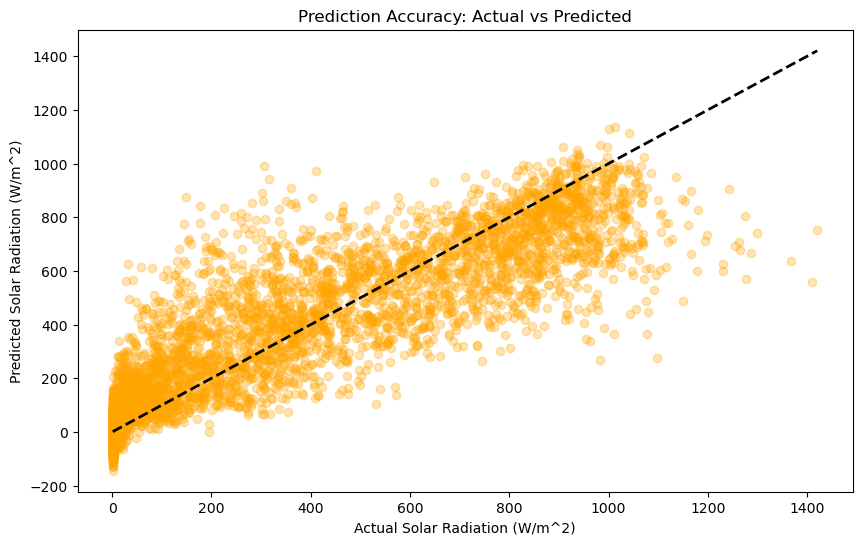

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(y_true_final, y_pred_final, alpha=0.3, color='orange')
plt.plot([y_true_final.min(), y_true_final.max()], 
         [y_true_final.min(), y_true_final.max()], 'k--', lw=2)
plt.xlabel('Actual Solar Radiation (W/m^2)')
plt.ylabel('Predicted Solar Radiation (W/m^2)')
plt.title('Prediction Accuracy: Actual vs Predicted')
plt.show()

The model has learned a good relationship between weather features and solar radiation. The prediction accuracy plot shows a good alignment between actual and predicted values along the ideal line, although there is visible scatter, indicating room for improvement, possibly by incorporating more features or a more complex model architecture

## 4d) Model Comparison with Ali et al. (2023)

### Our Model Performance
- **RMSE**: 126.78 MJ/m² day⁻¹
- **MAE**: 77.29 MJ/m² day⁻¹
- **R²**: 0.8383 (83.83%)

### Ali et al. (2023) Best Model Performance
- **RMSE**: 0.8361 MJ/m² day⁻¹
- **R²**: 0.9838 (98.38%)
- **Correlation (r)**: 0.9991
- **MAPE**: 4.34%
- **Architecture**: ANN with 3 neurons in single hidden layer

### Key Comparison

| Metric | Our Model | Ali et al. (2023) | Status |
|--------|-----------|-------------------|---------|
| RMSE | 126.78 | 0.8361 | Much higher because of range of Radiation |
| R² | 0.8383 | 0.9838 | Lower (15% gap) |
| Performance | Moderate | Excellent | Needs improvement |

**Differences**:
1. **Architecture**: Ali et al. found that **1-4 neurons** in hidden layer performed best
2. **Input features**: They used temperature + extraterrestrial radiation
3. **Training data**: 35 years of data

**Key Insight**: Ali et al. demonstrated that simpler ANN architectures (1-4 neurons) often outperform complex ones for solar radiation prediction while being computationally efficient. Our model's visible scatter and higher error suggest architectural optimization is needed.